# 论文实验图表

本 notebook 生成论文实验部分的所有图表，包括：
1. **Fig.1**: 动态场景方法对比（N=10, 4个速度）
2. **Fig.2**: 性能-计算权衡散点图
3. **Fig.3**: 规模扩展对比（N=10→50）
4. **Fig.4**: BC训练曲线（accuracy & eval P_int）
5. **Fig.5**: 消融实验（观测设计）
6. **Fig.6**: Zero-shot跨规模泛化
7. **Fig.7**: 失败分析（干扰源距离/频率差分布）

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = '../results_data'
FIG_DIR = 'figures'
import os
os.makedirs(FIG_DIR, exist_ok=True)

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

print('Data files available:')
for f in sorted(os.listdir(DATA_DIR)):
    print(f'  {f}')

Data files available:
  bc_orthogonal_N10_stats.json
  bc_orthogonal_N20_stats.json
  bc_orthogonal_N30_stats.json
  bc_orthogonal_N50_stats.json
  centralized_bc_N10_stats.json
  dist_N10_speed0.json
  dist_N10_speed10.json
  dist_N10_speed20.json
  dist_N10_speed30.json
  dist_N20_speed0.json
  dist_N20_speed20.json
  dynamic_bc_bc_orthogonal_N10.json
  dynamic_bc_bc_orthogonal_N20.json
  dynamic_bc_bc_orthogonal_N30.json
  dynamic_bc_bc_orthogonal_N50.json
  failure_analysis.json
  zeroshot_N10_deploy_speed20.json


## Fig.1: 动态场景方法对比 (N=10, 4个速度)

柱状图展示所有方法在不同移动速度下的累积互扰概率。

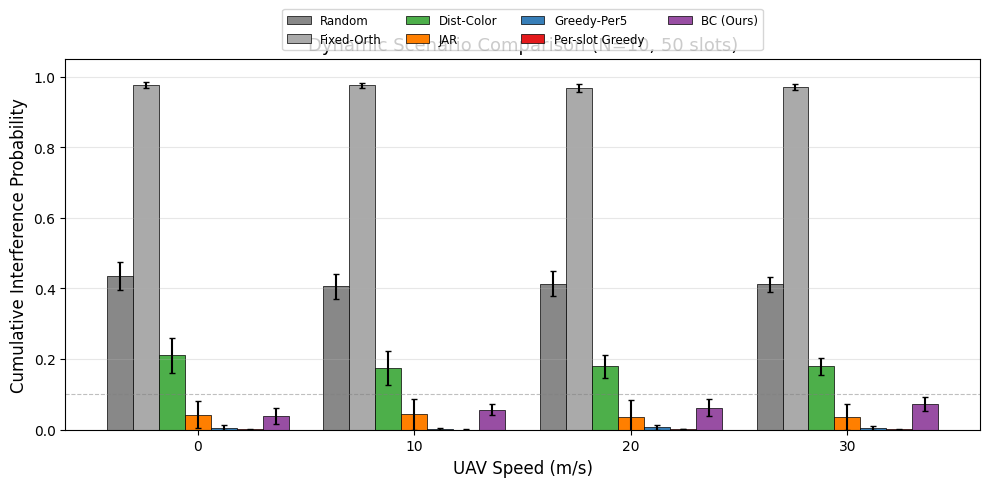

Fig.1 saved.


In [2]:
# 加载N=10分布式基线结果
speeds = [0, 10, 20, 30]
methods_order = ['random', 'fixed', 'dist_coloring', 'jar', 'greedy_periodic_5', 'greedy_per_slot']
method_labels = {
    'random': 'Random',
    'fixed': 'Fixed-Orth',
    'dist_coloring': 'Dist-Color',
    'jar': 'JAR',
    'greedy_periodic_5': 'Greedy-Per5',
    'greedy_per_slot': 'Per-slot Greedy',
}
method_colors = {
    'random': '#888888',
    'fixed': '#aaaaaa',
    'dist_coloring': '#4daf4a',
    'jar': '#ff7f00',
    'greedy_periodic_5': '#377eb8',
    'greedy_per_slot': '#e41a1c',
}

# 收集基线数据
baseline_data = {}
for speed in speeds:
    data = load_json(f'{DATA_DIR}/dist_N10_speed{speed}.json')
    for s in data['summary']:
        m = s['method']
        if m not in baseline_data:
            baseline_data[m] = {'probs': [], 'stds': [], 'times': []}
        baseline_data[m]['probs'].append(s['cum_interf_prob'])
        baseline_data[m]['stds'].append(s['std'])
        baseline_data[m]['times'].append(s['avg_time_s'])

# 加载BC动态结果
bc_dyn = load_json(f'{DATA_DIR}/dynamic_bc_bc_orthogonal_N10.json')
bc_probs = []
bc_stds = []
for speed in speeds:
    key = f'speed_{speed}'
    bc_probs.append(bc_dyn['results'][key]['cum_interf_prob_mean'])
    bc_stds.append(bc_dyn['results'][key]['cum_interf_prob_std'])

# 画图
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(speeds))
width = 0.12

all_methods = methods_order + ['bc']
all_labels = [method_labels[m] for m in methods_order] + ['BC (Ours)']
all_colors = [method_colors[m] for m in methods_order] + ['#984ea3']
all_probs = [baseline_data[m]['probs'] for m in methods_order] + [bc_probs]
all_stds = [baseline_data[m]['stds'] for m in methods_order] + [bc_stds]

for i, (label, color, probs, stds) in enumerate(zip(all_labels, all_colors, all_probs, all_stds)):
    offset = (i - len(all_methods)/2 + 0.5) * width
    bars = ax.bar(x + offset, probs, width, label=label, color=color, yerr=stds, capsize=2, edgecolor='black', linewidth=0.5)

ax.set_xlabel('UAV Speed (m/s)', fontsize=12)
ax.set_ylabel('Cumulative Interference Probability', fontsize=12)
ax.set_title('Dynamic Scenario Comparison (N=10, 50 slots)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in speeds])
ax.legend(ncol=4, fontsize=8.5, loc='upper center', bbox_to_anchor=(0.5, 1.15))
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_dynamic_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig1_dynamic_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig.1 saved.')

## Fig.2: 性能-计算权衡散点图

X轴: 推理时间(对数), Y轴: 互扰概率。展示BC在Pareto前沿。

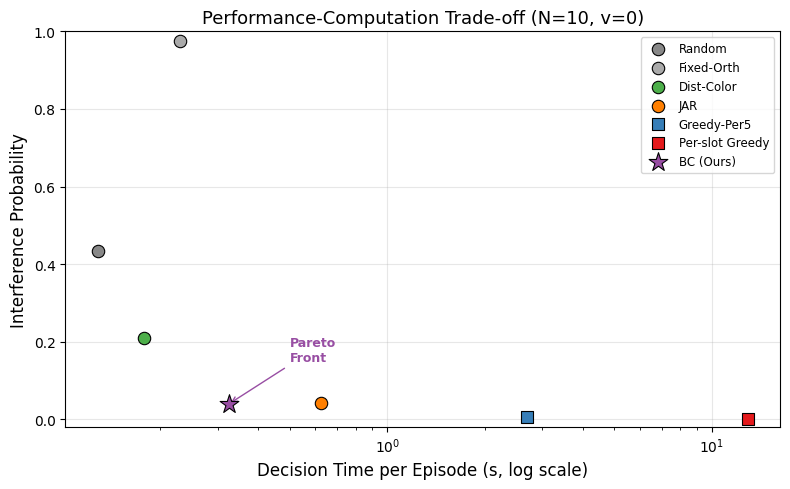

Fig.2 saved.


In [3]:
# 使用 speed=0 的数据
speed_idx = 0  # speed=0

scatter_data = []
for m in methods_order:
    scatter_data.append({
        'name': method_labels[m],
        'color': method_colors[m],
        'time': baseline_data[m]['times'][speed_idx],
        'prob': baseline_data[m]['probs'][speed_idx],
        'marker': 's' if 'Greedy' in method_labels[m] or 'Per-slot' in method_labels[m] else 'o',
    })

# BC
scatter_data.append({
    'name': 'BC (Ours)',
    'color': '#984ea3',
    'time': bc_dyn['results']['speed_0']['avg_total_inference_time_s'],
    'prob': bc_probs[0],
    'marker': '*',
})

fig, ax = plt.subplots(figsize=(8, 5))
for d in scatter_data:
    size = 200 if d['marker'] == '*' else 80
    ax.scatter(d['time'], d['prob'], c=d['color'], s=size, marker=d['marker'], 
              label=d['name'], edgecolors='black', linewidth=0.8, zorder=5)

ax.set_xscale('log')
ax.set_xlabel('Decision Time per Episode (s, log scale)', fontsize=12)
ax.set_ylabel('Interference Probability', fontsize=12)
ax.set_title('Performance-Computation Trade-off (N=10, v=0)', fontsize=13)
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.0)

# 标注Dist-Greedy（55s, 0.0）和BC
for d in scatter_data:
    if d['name'] == 'BC (Ours)':
        ax.annotate('Pareto\nFront', xy=(d['time'], d['prob']), 
                   xytext=(0.5, 0.15), fontsize=9, fontweight='bold',
                   arrowprops=dict(arrowstyle='->', color='#984ea3'),
                   color='#984ea3')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_tradeoff.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig2_tradeoff.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig.2 saved.')

## Fig.3: 规模扩展对比 (N=10→50)

左图: BC在各规模下的P_int (speed=0和speed=20)
右图: BC accuracy和推理时间随N的变化

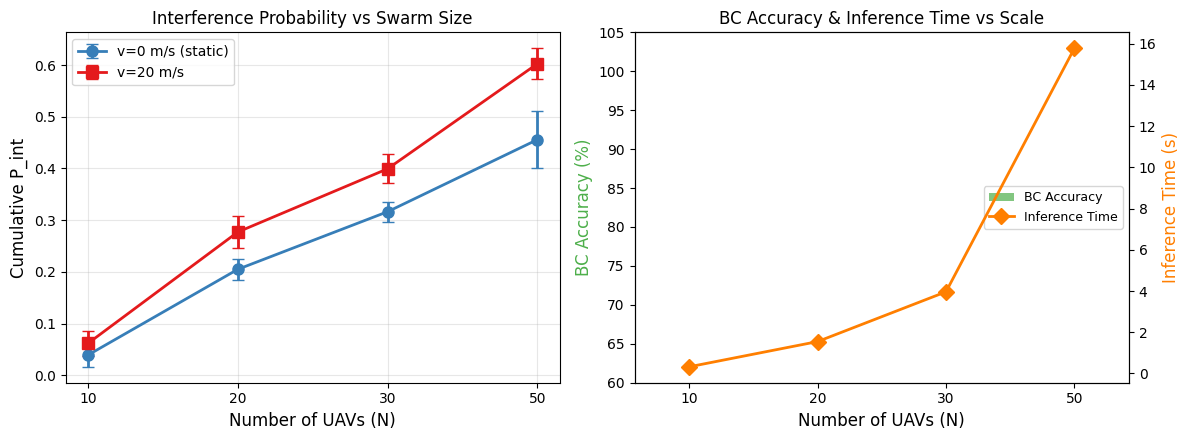

Fig.3 saved.


In [4]:
# 收集各规模BC动态结果
sizes = [10, 20, 30, 50]
bc_results = {}
for n in sizes:
    data = load_json(f'{DATA_DIR}/dynamic_bc_bc_orthogonal_N{n}.json')
    bc_results[n] = {
        'speed_0': data['results']['speed_0']['cum_interf_prob_mean'],
        'speed_0_std': data['results']['speed_0']['cum_interf_prob_std'],
        'speed_20': data['results']['speed_20']['cum_interf_prob_mean'],
        'speed_20_std': data['results']['speed_20']['cum_interf_prob_std'],
        'time_0': data['results']['speed_0']['avg_total_inference_time_s'],
    }

# 收集训练accuracy
bc_accs = {}
for n in sizes:
    stats = load_json(f'{DATA_DIR}/bc_orthogonal_N{n}_stats.json')
    bc_accs[n] = stats['acc'][-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 左图: P_int vs N
x = np.arange(len(sizes))
p0 = [bc_results[n]['speed_0'] for n in sizes]
p0_std = [bc_results[n]['speed_0_std'] for n in sizes]
p20 = [bc_results[n]['speed_20'] for n in sizes]
p20_std = [bc_results[n]['speed_20_std'] for n in sizes]

ax1.errorbar(x, p0, yerr=p0_std, marker='o', linewidth=2, markersize=8, capsize=4, 
             color='#377eb8', label='v=0 m/s (static)')
ax1.errorbar(x, p20, yerr=p20_std, marker='s', linewidth=2, markersize=8, capsize=4,
             color='#e41a1c', label='v=20 m/s')
ax1.set_xlabel('Number of UAVs (N)', fontsize=12)
ax1.set_ylabel('Cumulative P_int', fontsize=12)
ax1.set_title('Interference Probability vs Swarm Size', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([str(n) for n in sizes])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 右图: Accuracy & Inference Time
accs = [bc_accs[n] for n in sizes]
times = [bc_results[n]['time_0'] for n in sizes]

ax2b = ax2.twinx()
bars = ax2.bar(x, accs, 0.5, color='#4daf4a', alpha=0.7, label='BC Accuracy')
line = ax2b.plot(x, times, marker='D', color='#ff7f00', linewidth=2, markersize=8, label='Inference Time')

ax2.set_xlabel('Number of UAVs (N)', fontsize=12)
ax2.set_ylabel('BC Accuracy (%)', fontsize=12, color='#4daf4a')
ax2b.set_ylabel('Inference Time (s)', fontsize=12, color='#ff7f00')
ax2.set_title('BC Accuracy & Inference Time vs Scale', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([str(n) for n in sizes])
ax2.set_ylim(60, 105)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_scale.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig3_scale.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig.3 saved.')

## Fig.4: BC训练曲线

展示N=10/20/30/50的BC训练过程中的accuracy和eval P_int变化。

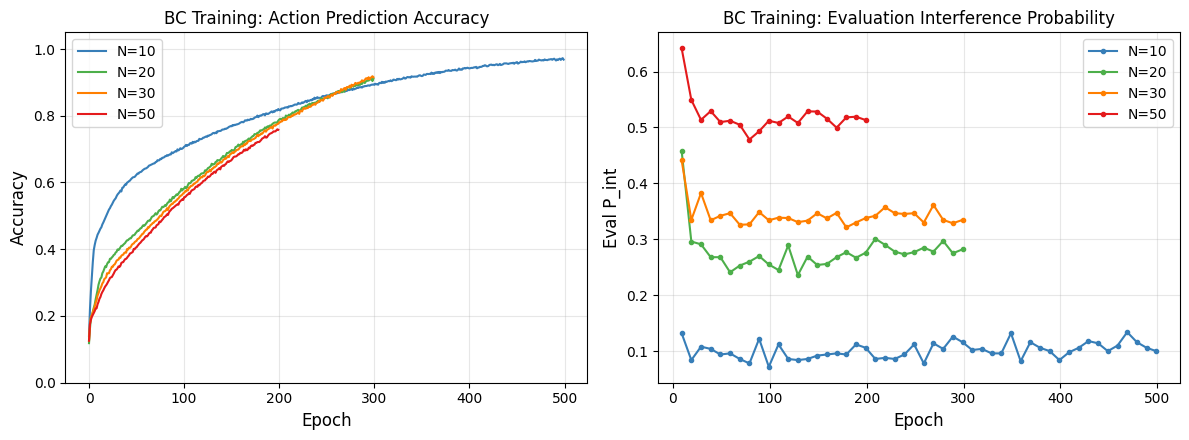

Fig.4 saved.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
colors_n = {10: '#377eb8', 20: '#4daf4a', 30: '#ff7f00', 50: '#e41a1c'}

for n in sizes:
    stats = load_json(f'{DATA_DIR}/bc_orthogonal_N{n}_stats.json')
    epochs = stats['epoch']
    accs = stats['acc']
    evals = stats.get('eval_interf_probs', [])
    
    ax1.plot(epochs, accs, linewidth=1.5, color=colors_n[n], label=f'N={n}')
    
    # eval P_int (每eval_interval个epoch一次)
    eval_interval = 10
    eval_epochs = [e for i, e in enumerate(range(eval_interval-1, len(epochs), eval_interval)) if i < len(evals)]
    if eval_epochs:
        ax2.plot(eval_epochs, evals[:len(eval_epochs)], linewidth=1.5, marker='o', markersize=3, 
                color=colors_n[n], label=f'N={n}')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('BC Training: Action Prediction Accuracy', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Eval P_int', fontsize=12)
ax2.set_title('BC Training: Evaluation Interference Probability', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_training.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig4_training.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig.4 saved.')

## Fig.5: 消融实验

对比4种观测设计的BC accuracy和P_int。

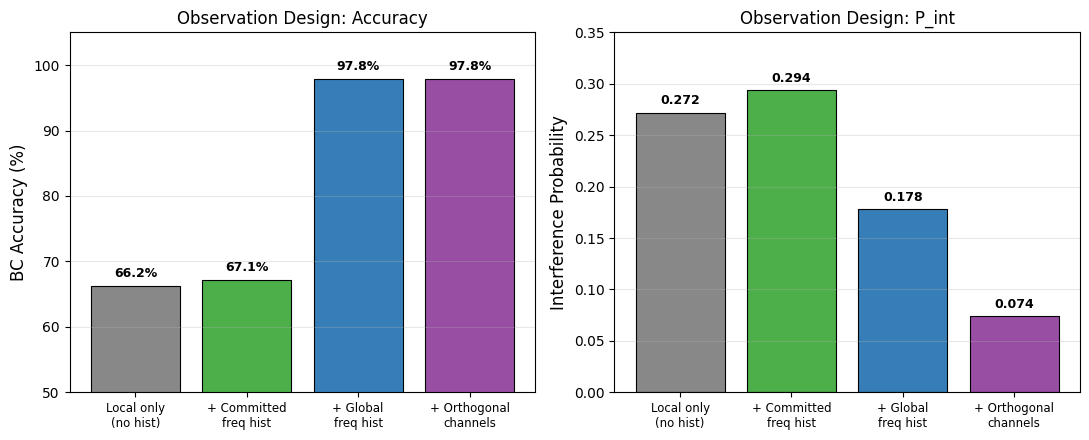

Fig.5 saved.


In [6]:
# 消融数据（从之前的实验记录中整理）
ablation_data = {
    'Local only\n(no hist)': {'obs_dim': 58, 'acc': 66.2, 'p_int': 0.272, 'n_freq': 20},
    '+ Committed\nfreq hist': {'obs_dim': 78, 'acc': 67.1, 'p_int': 0.294, 'n_freq': 20},
    '+ Global\nfreq hist': {'obs_dim': 98, 'acc': 97.8, 'p_int': 0.178, 'n_freq': 20},
    '+ Orthogonal\nchannels': {'obs_dim': 78, 'acc': 97.8, 'p_int': 0.074, 'n_freq': 10},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
labels = list(ablation_data.keys())
accs = [ablation_data[k]['acc'] for k in labels]
probs = [ablation_data[k]['p_int'] for k in labels]
colors_ab = ['#888888', '#4daf4a', '#377eb8', '#984ea3']

bars1 = ax1.bar(range(len(labels)), accs, color=colors_ab, edgecolor='black', linewidth=0.8)
ax1.set_ylabel('BC Accuracy (%)', fontsize=12)
ax1.set_title('Observation Design: Accuracy', fontsize=12)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=8.5)
ax1.set_ylim(50, 105)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = ax2.bar(range(len(labels)), probs, color=colors_ab, edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Interference Probability', fontsize=12)
ax2.set_title('Observation Design: P_int', fontsize=12)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=8.5)
ax2.set_ylim(0, 0.35)
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, probs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_ablation.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig5_ablation.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig.5 saved.')

## Fig.6: Zero-shot 跨规模泛化

用N=10训练的模型直接部署到N=20/30/50的结果。

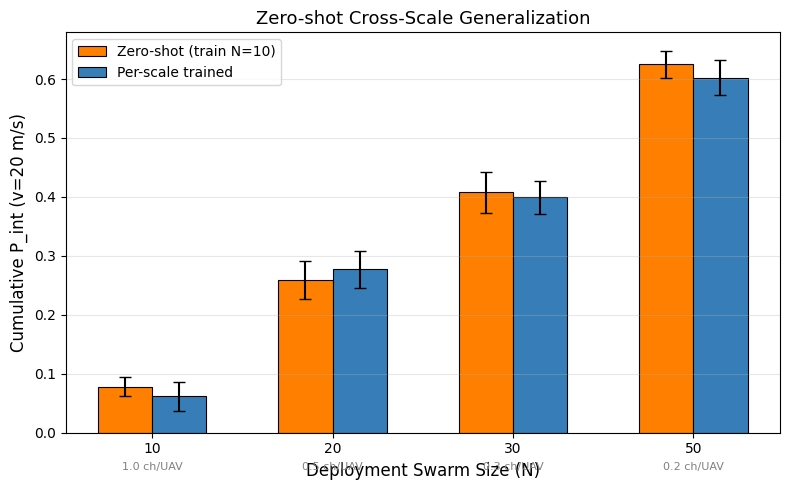

Fig.6 saved.


In [7]:
zs = load_json(f'{DATA_DIR}/zeroshot_N10_deploy_speed20.json')
deploy_sizes = [10, 20, 30, 50]
zs_probs = [zs['results'][f'N{n}']['cum_interf_prob'] for n in deploy_sizes]
zs_stds = [zs['results'][f'N{n}']['std'] for n in deploy_sizes]
zs_times = [zs['results'][f'N{n}']['avg_time_s'] for n in deploy_sizes]

# 对比：各自训练的BC
trained_probs = [bc_results[n]['speed_20'] for n in deploy_sizes]
trained_stds = [bc_results[n]['speed_20_std'] for n in deploy_sizes]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(deploy_sizes))
width = 0.3

bars1 = ax.bar(x - width/2, zs_probs, width, yerr=zs_stds, capsize=4, 
               color='#ff7f00', edgecolor='black', linewidth=0.8, label='Zero-shot (train N=10)')
bars2 = ax.bar(x + width/2, trained_probs, width, yerr=trained_stds, capsize=4,
               color='#377eb8', edgecolor='black', linewidth=0.8, label='Per-scale trained')

ax.set_xlabel('Deployment Swarm Size (N)', fontsize=12)
ax.set_ylabel('Cumulative P_int (v=20 m/s)', fontsize=12)
ax.set_title('Zero-shot Cross-Scale Generalization', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in deploy_sizes])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 标注信道/UAV比
for i, n in enumerate(deploy_sizes):
    ratio = 10 / n
    ax.text(i, -0.05, f'{ratio:.1f} ch/UAV', ha='center', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_zeroshot.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig6_zeroshot.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig.6 saved.')

## Fig.7: 失败分析

左图: 干扰源距离分布
右图: 干扰源频率差分布

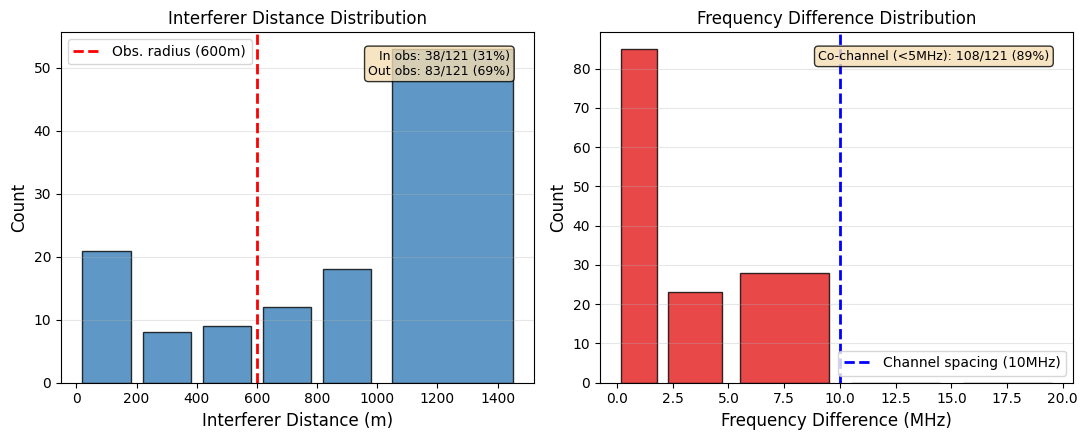

Fig.7 saved.


In [8]:
# 使用统计数据直接画图（failure_analysis.json被截断）
# 从之前的分析中提取的手动数据
distances_bins = [0, 200, 400, 600, 800, 1000, 1500]
distances_counts = [21, 8, 9, 12, 18, 53]  # 各区间的干扰对数量
freq_diff_bins = [0, 2, 5, 10, 15, 20]
freq_diff_counts = [85, 23, 28, 0, 0]  # 各区间的频率差对数量
total_pairs = sum(distances_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 左图: 距离分布
bar_centers = [(distances_bins[i]+distances_bins[i+1])/2 for i in range(len(distances_counts))]
bar_widths = [distances_bins[i+1]-distances_bins[i] for i in range(len(distances_counts))]
ax1.bar(bar_centers, distances_counts, width=[w*0.8 for w in bar_widths], color='#377eb8', edgecolor='black', alpha=0.8)
ax1.axvline(x=600, color='red', linestyle='--', linewidth=2, label='Obs. radius (600m)')
ax1.set_xlabel('Interferer Distance (m)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Interferer Distance Distribution', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

in_obs = sum(distances_counts[:3])  # <600m
out_obs = sum(distances_counts[3:])  # >=600m
ax1.text(0.95, 0.95, f'In obs: {in_obs}/{total_pairs} ({100*in_obs/total_pairs:.0f}%)\nOut obs: {out_obs}/{total_pairs} ({100*out_obs/total_pairs:.0f}%)',
        transform=ax1.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 右图: 频率差分布
bar_centers_f = [(freq_diff_bins[i]+freq_diff_bins[i+1])/2 for i in range(len(freq_diff_counts))]
bar_widths_f = [freq_diff_bins[i+1]-freq_diff_bins[i] for i in range(len(freq_diff_counts))]
ax2.bar(bar_centers_f, freq_diff_counts, width=[w*0.8 for w in bar_widths_f], color='#e41a1c', edgecolor='black', alpha=0.8)
ax2.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='Channel spacing (10MHz)')
ax2.set_xlabel('Frequency Difference (MHz)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Frequency Difference Distribution', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

co_channel = sum(freq_diff_counts[:2])  # <5MHz
ax2.text(0.95, 0.95, f'Co-channel (<5MHz): {co_channel}/{total_pairs} ({100*co_channel/total_pairs:.0f}%)',
        transform=ax2.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig7_failure_analysis.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig7_failure_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print('Fig.7 saved.')

## 总结

所有图表已生成并保存至 `paper/figures/` 目录：

| 图号 | 文件名 | 内容 |
|------|--------|------|
| Fig.1 | fig1_dynamic_comparison | 动态场景方法对比柱状图 |
| Fig.2 | fig2_tradeoff | 性能-计算权衡散点图 |
| Fig.3 | fig3_scale | 规模扩展（P_int + accuracy/time） |
| Fig.4 | fig4_training | BC训练曲线 |
| Fig.5 | fig5_ablation | 消融实验 |
| Fig.6 | fig6_zeroshot | Zero-shot泛化 |
| Fig.7 | fig7_failure_analysis | 失败分析 |